In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import yfinance as yf



# Pre-processing c.o. jaguar


--- Processing AAPL ---


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_3036/4261995138.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start='2022-01-01', end='2025-01-01', progress=False)


Saved historical data to AAPL_historical.csv

--- Processing MSFT ---


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_3036/4261995138.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start='2022-01-01', end='2025-01-01', progress=False)


Saved historical data to MSFT_historical.csv

Generating Comparison Plot...
Saved comparison chart to portfolio_comparison.png


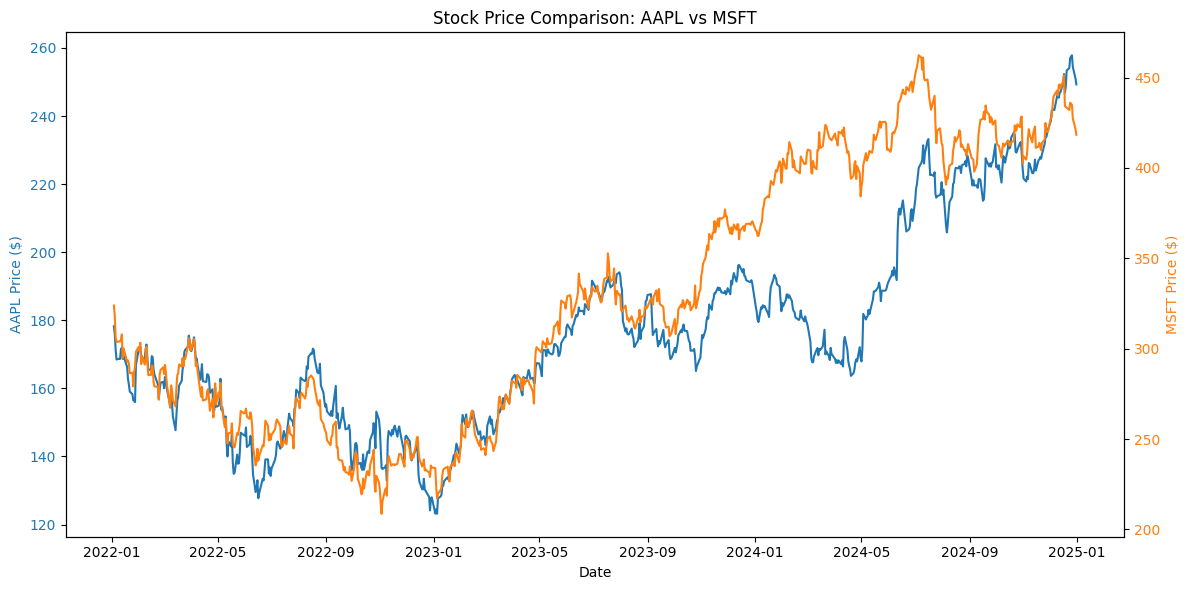


--- Pipeline Complete ---
Generated files: AAPL_historical.csv, MSFT_historical.csv, portfolio_comparison.png


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_and_clean_stock_data(ticker_symbol, save_csv=True):
    print(f"\n--- Processing {ticker_symbol} ---")
    
    # 1. Ingestion: Fetch data with strict dates
    # Case Requirement: Jan 1, 2022 to Jan 1, 2025 [cite: 50]
    df = yf.download(ticker_symbol, start='2022-01-01', end='2025-01-01', progress=False)
    
    # 2. Check for Empty Data
    if df.empty:
        raise ValueError(f"No data found for {ticker_symbol}. Check ticker symbol.")

    # 3. Feature Selection: Robust Column Flattening
    # This handles the complex MultiIndex that yfinance sometimes returns
    if isinstance(df.columns, pd.MultiIndex):
        try:
            if 'Close' in df.columns.get_level_values(0):
                df = df.xs('Close', axis=1, level=0, drop_level=True)
            elif 'Close' in df.columns.get_level_values(1):
                df = df.xs('Close', axis=1, level=1, drop_level=True)
        except KeyError:
            pass
            
    if 'Close' in df.columns:
        data = df[['Close']].copy()
    else:
        # Fallback for single-column returns
        data = df.iloc[:, 0].to_frame(name='Close')

    # 4. Missing Values
    if data.isnull().values.any():
        print(f"Found {data.isnull().sum()} missing values. Forward filling...")
        data = data.ffill().bfill()
        
    # 5. Outlier Detection
    pct_change = data['Close'].pct_change()
    if (np.abs(pct_change) > 0.5).any():
        print(f"WARNING: Large spikes detected in {ticker_symbol}.")

    # 6. REQUIRED: Save to CSV
    if save_csv:
        filename = f"{ticker_symbol}_historical.csv"
        data.to_csv(filename)
        print(f"Saved historical data to {filename}")
    
    return data

def plot_two_stocks(data1, name1, data2, name2):
    """
    Plots two stocks on the same chart using dual axes (left and right)
    so you can compare trends even if prices are very different.
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'{name1} Price ($)', color=color)
    ax1.plot(data1.index, data1['Close'], color=color, label=name1)
    ax1.tick_params(axis='y', labelcolor=color)

    # Instantiate a second axes that shares the same x-axis
    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel(f'{name2} Price ($)', color=color)
    ax2.plot(data2.index, data2['Close'], color=color, label=name2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Stock Price Comparison: {name1} vs {name2}')
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    
    # Save the comparison chart
    plt.savefig("portfolio_comparison.png")
    print("Saved comparison chart to portfolio_comparison.png")
    plt.show()

# --- MAIN EXECUTION BLOCK ---
if __name__ == "__main__":
    
    # ==========================================
    # INPUT YOUR 2 CHOSEN STOCKS HERE
    # ==========================================
    MY_STOCKS = ['AAPL', 'MSFT'] 
    # ==========================================

    stock_data_store = {}

    try:
        # Loop through the list and process each stock
        for ticker in MY_STOCKS:
            df = get_and_clean_stock_data(ticker)
            stock_data_store[ticker] = df
        
        # Plot them together
        print("\nGenerating Comparison Plot...")
        plot_two_stocks(
            stock_data_store[MY_STOCKS[0]], MY_STOCKS[0],
            stock_data_store[MY_STOCKS[1]], MY_STOCKS[1]
        )
        
        print("\n--- Pipeline Complete ---")
        print(f"Generated files: {MY_STOCKS[0]}_historical.csv, {MY_STOCKS[1]}_historical.csv, portfolio_comparison.png")
        
    except Exception as e:
        print(f"An error occurred: {e}")


# (old) Modeling AAPL and MSFT

## AAPL

In [4]:
# Ensure proper DateTimeIndex,numeric Close column, and sorted data

aapl_data = pd.read_csv('AAPL_historical.csv')
aapl_data['Date'] = pd.to_datetime(aapl_data['Date'])
aapl_data = aapl_data.set_index('Date').sort_index()
aapl_data['Close'] = pd.to_numeric(aapl_data['Close'], errors='coerce')
aapl_data = aapl_data.dropna() # Drop na

aapl_data.head()



,Close
Date,
2022-01-03,178.270309
2022-01-04,176.007767
2022-01-05,171.325974
2022-01-06,168.465988
2022-01-07,168.632507


In [ ]:
aapl_ma = aapl_data['Close'].rolling(window=7).mean()

In [5]:

aapl_train = aapl_data.iloc[:-60] # Train set == before jan 1 2025
aapl_test  = aapl_data.iloc[-60:] # Test set == after jan 1 2025

aapl_train.shape, aapl_test.shape

((693, 1), (60, 1))

In [6]:
# Stationarity tests
# Recall that if ADF < 0.05 and KPSS > 0.05, the series is stationary
aapl_adf_p = adfuller(aapl_train['Close'])[1]
aapl_kpss_p = kpss(aapl_train['Close'])[1]

print("AAPL ADF p-value:", aapl_adf_p)
print("AAPL KPSS p-value:", aapl_kpss_p)

AAPL ADF p-value: 0.8362226665126327
AAPL KPSS p-value: 0.01


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_1866/3662497917.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  aapl_kpss_p = kpss(aapl_train['Close'])[1]


In [7]:
# Apply first order differencing; Drops the first NaN created by differencing

aapl_diff1 = aapl_train['Close'].diff().dropna()
aapl_diff1.head()

Date
2022-01-04   -2.262543
2022-01-05   -4.681793
2022-01-06   -2.859985
2022-01-07    0.166519
2022-01-10    0.019577
Name: Close, dtype: float64

In [8]:
# Re-run stationarity
aapl_adf_p2 = adfuller(aapl_diff1)[1]
aapl_kpss_p2 = kpss(aapl_diff1)[1]

print("AAPL ADF after differencing:", aapl_adf_p2)
print("AAPL KPSS after differencing:", aapl_kpss_p2)

AAPL ADF after differencing: 0.0
AAPL KPSS after differencing: 0.1


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_1866/1919112035.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  aapl_kpss_p2 = kpss(aapl_diff1)[1]


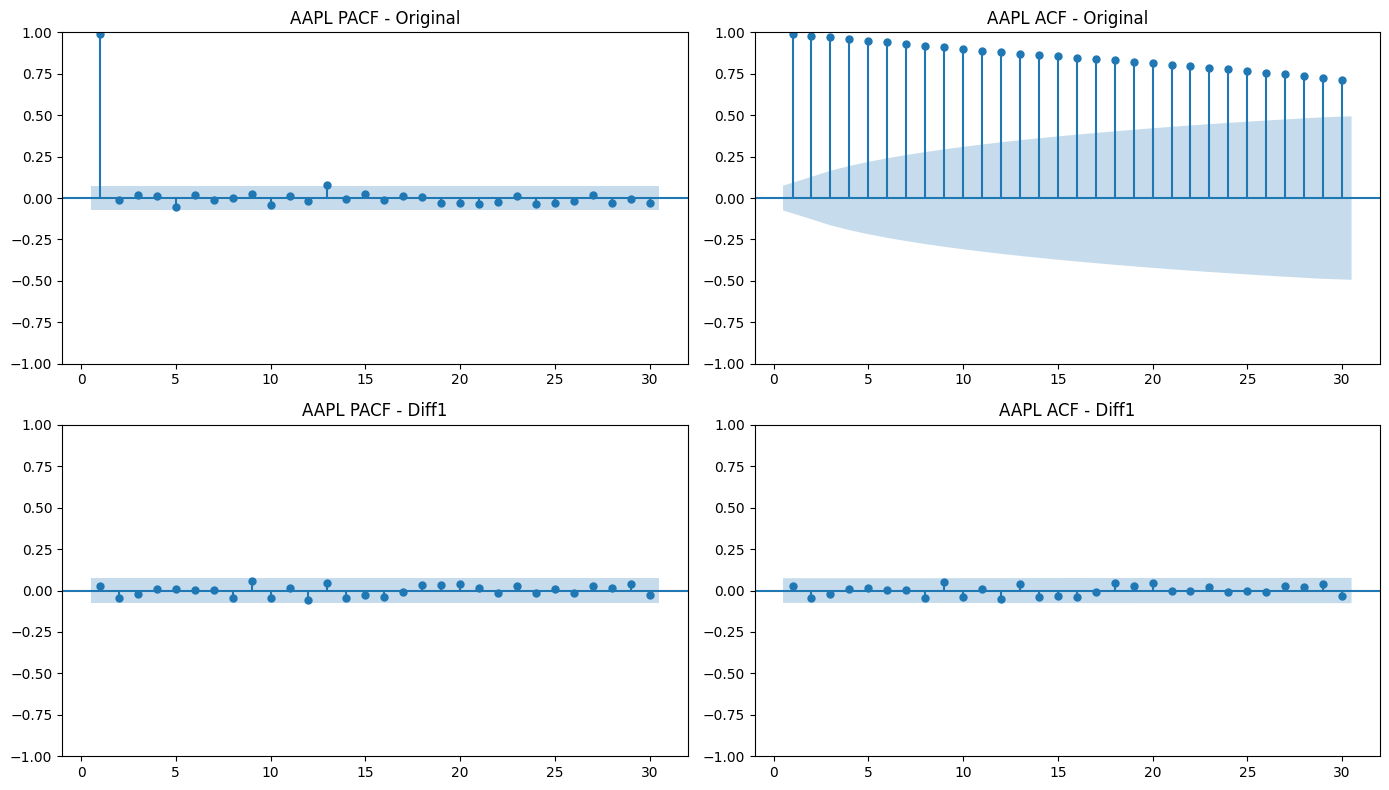

In [9]:
"""
ACF & PACF before and after differencing for AAPL.
"""

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

plot_pacf(aapl_train['Close'], lags=30, ax=ax[0,0], zero=False)
ax[0,0].set_title("AAPL PACF - Original")

plot_acf(aapl_train['Close'], lags=30, ax=ax[0,1], zero=False)
ax[0,1].set_title("AAPL ACF - Original")

plot_pacf(aapl_diff1, lags=30, ax=ax[1,0], zero=False)
ax[1,0].set_title("AAPL PACF - Diff1")

plot_acf(aapl_diff1, lags=30, ax=ax[1,1], zero=False)
ax[1,1].set_title("AAPL ACF - Diff1")

plt.tight_layout()
plt.show()


In [10]:
"""
Fits an ARIMA(p,d,q) model based on ACF/PACF analysis.
For AAPL, p=2, d=1, q=1 is typically reasonable.
Stores the fitted model for forecasting.
"""

aapl_arima = ARIMA(aapl_train['Close'], order=(2,1,1))
aapl_fit = aapl_arima.fit()

aapl_fit.summary()


/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  693
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -1707.968
Date:                Fri, 21 Nov 2025   AIC                           3423.937
Time:                        14:46:26   BIC                           3442.095
Sample:                             0   HQIC                          3430.960
                                - 693                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2463      0.802      0.307      0.759      -1.326       1.819
ar.L2         -0.0508      0.043     -1.175      0.240      -0.136       0.034
ma.L1         -0.2188      0.808     -0.271      0.787      -1.803       1.365
sigma2         8.1524      0.322     25.305      0.000       7.521       8.784
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               133.11
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.69   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
"""
Generates 60-step forecasts using the fitted ARIMA model
and computes MSE against actual test values.
"""


aapl_arima_preds = aapl_fit.forecast(steps=60)
aapl_mse_arima = mean_squared_error(aapl_test['Close'], aapl_arima_preds)

print("AAPL ARIMA MSE:", aapl_mse_arima)



AAPL ARIMA MSE: 204.85223280688385


/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [12]:
"""
Implements a naive (random walk) baseline forecast.
Forecasts the next 60 points using the last observed training value.
Equivalent to ARIMA(0,1,0).
"""

aapl_naive = np.repeat(aapl_train['Close'].iloc[-1], 60)
aapl_mse_naive = mean_squared_error(aapl_test['Close'], aapl_naive)

print("AAPL Naive MSE:", aapl_mse_naive)



AAPL Naive MSE: 205.55063663930193


In [13]:
"""
Creates a supervised lagged dataset for ML forecasting.
Resetting the index ensures shift() aligns properly with row order.
"""

def make_lagged(series, nlags=30):
    s = pd.Series(series).reset_index(drop=True)
    nlags = min(nlags, len(s) - 2)

    out = pd.DataFrame({'y': s})
    for i in range(1, nlags+1):
        out[f'lag_{i}'] = s.shift(i)
    return out.dropna()

aapl_lagged = make_lagged(aapl_train['Close'], 30)
print(aapl_lagged.shape)
aapl_lagged.head()

(663, 31)


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30
30,169.455353,165.620819,165.385452,168.798264,172.878052,171.456024,168.347229,169.063065,169.347488,172.227081,...,169.514023,168.652084,171.923447,171.482712,168.652084,168.632507,168.465988,171.325974,176.007767,178.270309
31,169.220032,169.455353,165.620819,165.385452,168.798264,172.878052,171.456024,168.347229,169.063065,169.347488,...,166.311203,169.514023,168.652084,171.923447,171.482712,168.652084,168.632507,168.465988,171.325974,176.007767
32,165.620819,169.220032,169.455353,165.620819,165.385452,168.798264,172.878052,171.456024,168.347229,169.063065,...,162.814529,166.311203,169.514023,168.652084,171.923447,171.482712,168.652084,168.632507,168.465988,171.325974
33,164.071289,165.620819,169.220032,169.455353,165.620819,165.385452,168.798264,172.878052,171.456024,168.347229,...,161.129913,162.814529,166.311203,169.514023,168.652084,171.923447,171.482712,168.652084,168.632507,168.465988
34,161.148849,164.071289,165.620819,169.220032,169.455353,165.620819,165.385452,168.798264,172.878052,171.456024,...,159.073013,161.129913,162.814529,166.311203,169.514023,168.652084,171.923447,171.482712,168.652084,168.632507


In [14]:
"""
Fits a Linear Regression model on lagged features.
"""

aapl_X = aapl_lagged.drop(columns='y')
aapl_y = aapl_lagged['y']

aapl_lr = LinearRegression()
aapl_lr.fit(aapl_X, aapl_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
"""
Generates 60-step recursive forecasts using the trained regression model.
Each prediction is fed back as the newest lag for the next iteration.
"""

aapl_last_vals = aapl_train['Close'].reset_index(drop=True).iloc[-30:].values
aapl_ml_preds = []

for _ in range(60):
    X_input = aapl_last_vals[::-1].reshape(1,-1)
    pred = aapl_lr.predict(X_input)[0]
    aapl_ml_preds.append(pred)
    aapl_last_vals = np.append(aapl_last_vals[1:], pred)

aapl_mse_ml = mean_squared_error(aapl_test['Close'], aapl_ml_preds)

print("AAPL Lag Regression MSE:", aapl_mse_ml)


AAPL Lag Regression MSE: 364.98365589140434


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3

In [16]:
"""
Prints Mean Squared Error (MSE) for all forecasting models:
1) ARIMA
2) Naive Random Walk
3) Lagged Linear Regression

Used to choose final model for 60-day hackathon forecast submission.
"""

print("ARIMA(2,1,1) MSE:", aapl_mse_arima)
print("Naive Baseline MSE:", aapl_mse_naive)
print("Lag Regression MSE:", aapl_mse_ml)


ARIMA(2,1,1) MSE: 204.85223280688385
Naive Baseline MSE: 205.55063663930193
Lag Regression MSE: 364.98365589140434


## MSFT

In [17]:
"""
Load and clean MSFT historical data.
"""

msft_data = pd.read_csv('MSFT_historical.csv')
msft_data['Date'] = pd.to_datetime(msft_data['Date'])
msft_data = msft_data.set_index('Date').sort_index()
msft_data['Close'] = pd.to_numeric(msft_data['Close'], errors='coerce')
msft_data = msft_data.dropna()

msft_data.head()


,Close
Date,
2022-01-03,323.898376
2022-01-04,318.344482
2022-01-05,306.123871
2022-01-06,303.704895
2022-01-07,303.859772


In [18]:
"""
Create 60-day train/test split for MSFT.
"""

msft_train = msft_data.iloc[:-60]
msft_test  = msft_data.iloc[-60:]

msft_train.shape, msft_test.shape


((693, 1), (60, 1))

In [19]:
"""
ADF and KPSS for MSFT.
"""

msft_adf_p = adfuller(msft_train['Close'])[1]
msft_kpss_p = kpss(msft_train['Close'])[1]

print("MSFT ADF p-value:", msft_adf_p)
print("MSFT KPSS p-value:", msft_kpss_p)


MSFT ADF p-value: 0.9109010720643651
MSFT KPSS p-value: 0.01


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_1866/1943957181.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  msft_kpss_p = kpss(msft_train['Close'])[1]


In [20]:
"""
First-order differencing for MSFT.
"""

msft_diff1 = msft_train['Close'].diff().dropna()
msft_diff1.head()


Date
2022-01-04    -5.553894
2022-01-05   -12.220612
2022-01-06    -2.418976
2022-01-07     0.154877
2022-01-10     0.222504
Name: Close, dtype: float64

In [21]:
"""
ADF and KPSS after differencing for MSFT.
"""

msft_adf_p2 = adfuller(msft_diff1)[1]
msft_kpss_p2 = kpss(msft_diff1)[1]

print("MSFT ADF after differencing:", msft_adf_p2)
print("MSFT KPSS after differencing:", msft_kpss_p2)


MSFT ADF after differencing: 0.0
MSFT KPSS after differencing: 0.1


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_1866/2411092853.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  msft_kpss_p2 = kpss(msft_diff1)[1]


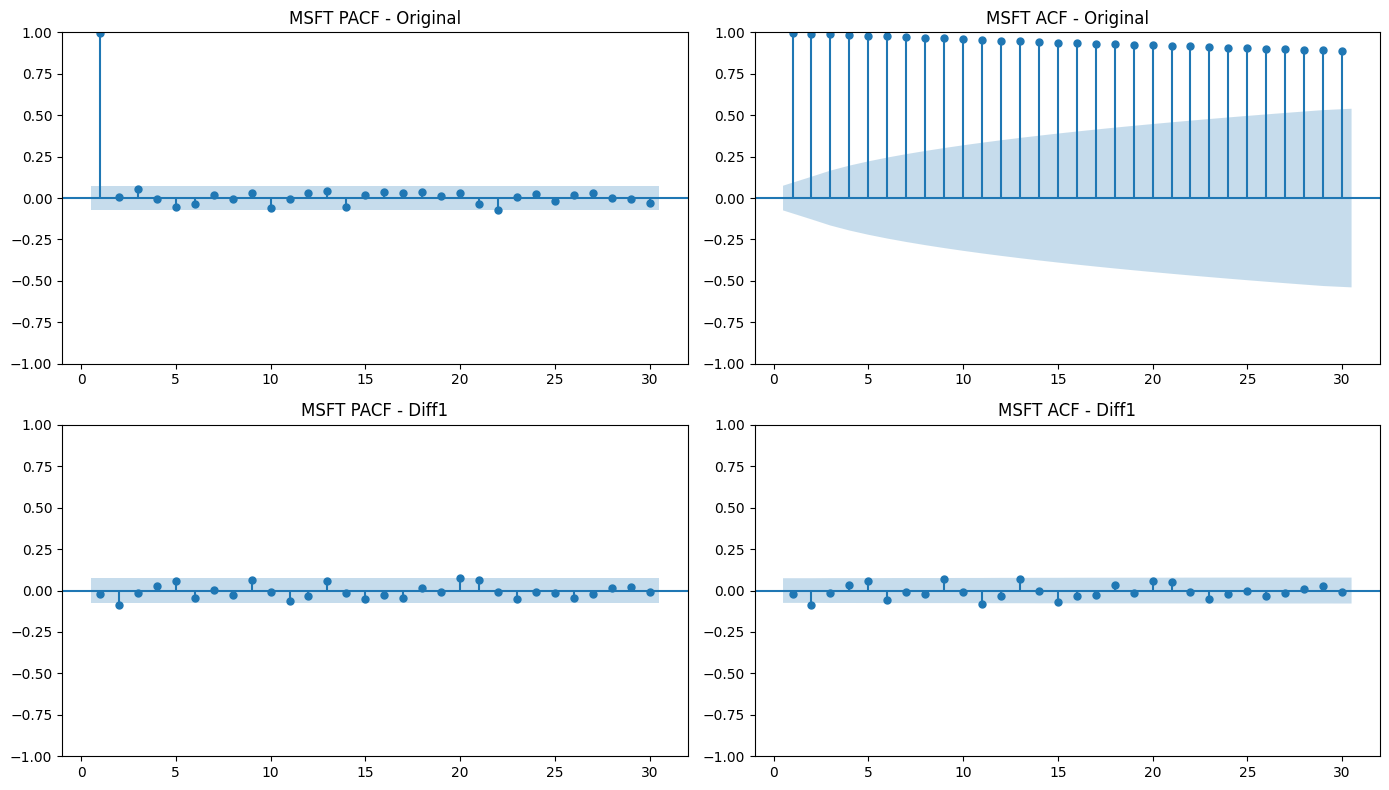

In [22]:
"""
ACF & PACF before and after differencing for MSFT.
"""

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

plot_pacf(msft_train['Close'], lags=30, ax=ax[0,0], zero=False)
ax[0,0].set_title("MSFT PACF - Original")

plot_acf(msft_train['Close'], lags=30, ax=ax[0,1], zero=False)
ax[0,1].set_title("MSFT ACF - Original")

plot_pacf(msft_diff1, lags=30, ax=ax[1,0], zero=False)
ax[1,0].set_title("MSFT PACF - Diff1")

plot_acf(msft_diff1, lags=30, ax=ax[1,1], zero=False)
ax[1,1].set_title("MSFT ACF - Diff1")

plt.tight_layout()
plt.show()


In [23]:
"""
Fit ARIMA model for MSFT.
"""

msft_arima = ARIMA(msft_train['Close'], order=(2,1,1))
msft_fit = msft_arima.fit()

msft_fit.summary()


/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  693
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -2119.968
Date:                Fri, 21 Nov 2025   AIC                           4247.937
Time:                        14:46:28   BIC                           4266.095
Sample:                             0   HQIC                          4254.960
                                - 693                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0838      0.428      0.196      0.845      -0.755       0.923
ar.L2         -0.0858      0.039     -2.186      0.029      -0.163      -0.009
ma.L1         -0.1040      0.429     -0.242      0.808      -0.944       0.737
sigma2        26.8211      1.304     20.575      0.000      24.266      29.376
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                10.98
Prob(Q):                              0.98   Prob(JB):                         0.00
Heteroskedasticity (H):               0.70   Skew:                            -0.14
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.55
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
"""
Generate MSFT ARIMA forecast and compute MSE.
"""

msft_arima_preds = msft_fit.forecast(steps=60)
msft_mse_arima = mean_squared_error(msft_test['Close'], msft_arima_preds)

print("MSFT ARIMA MSE:", msft_mse_arima)


MSFT ARIMA MSE: 257.0651159373861


/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [25]:
"""
MSFT random-walk baseline forecast.
"""

msft_naive = np.repeat(msft_train['Close'].iloc[-1], 60)
msft_mse_naive = mean_squared_error(msft_test['Close'], msft_naive)

print("MSFT Naive MSE:", msft_mse_naive)


MSFT Naive MSE: 260.1133295695608


In [26]:
"""
Lag feature creation for MSFT ML model.
"""

msft_lagged = make_lagged(msft_train['Close'], 30)
print(msft_lagged.shape)
msft_lagged.head()


(663, 31)


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30
30,290.729614,285.436951,285.475647,292.577667,301.121460,294.687073,291.194092,296.022339,291.484344,303.298584,...,300.144226,294.919220,307.952667,304.769257,304.082275,303.859772,303.704895,306.123871,318.344482,323.898376
31,290.390320,290.729614,285.436951,285.475647,292.577667,301.121460,294.687073,291.194092,296.022339,291.484344,...,292.838959,300.144226,294.919220,307.952667,304.769257,304.082275,303.859772,303.704895,306.123871,318.344482
32,281.887085,290.390320,290.729614,285.436951,285.475647,292.577667,301.121460,294.687073,291.194092,296.022339,...,293.496918,292.838959,300.144226,294.919220,307.952667,304.769257,304.082275,303.859772,303.704895,306.123871
33,279.172241,281.887085,290.390320,290.729614,285.436951,285.475647,292.577667,301.121460,294.687073,291.194092,...,291.822998,293.496918,292.838959,300.144226,294.919220,307.952667,304.769257,304.082275,303.859772,303.704895
34,278.968658,279.172241,281.887085,290.390320,290.729614,285.436951,285.475647,292.577667,301.121460,294.687073,...,286.433594,291.822998,293.496918,292.838959,300.144226,294.919220,307.952667,304.769257,304.082275,303.859772


In [27]:
"""
Train MSFT lag regression model.
"""

msft_X = msft_lagged.drop(columns='y')
msft_y = msft_lagged['y']

msft_lr = LinearRegression()
msft_lr.fit(msft_X, msft_y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
"""
Recursive ML forecasting for MSFT.
"""

msft_last_vals = msft_train['Close'].reset_index(drop=True).iloc[-30:].values
msft_ml_preds = []

for _ in range(60):
    X_input = msft_last_vals[::-1].reshape(1,-1)
    pred = msft_lr.predict(X_input)[0]
    msft_ml_preds.append(pred)
    msft_last_vals = np.append(msft_last_vals[1:], pred)

msft_mse_ml = mean_squared_error(msft_test['Close'], msft_ml_preds)

print("MSFT Lag Regression MSE:", msft_mse_ml)


MSFT Lag Regression MSE: 126.1145439074137


/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3

# Modeling AAPL; Full decomposition + full reconstruction (Trend + Season + Forecasted Residual)

In [4]:
"""
Load AAPL close prices and enforce business-day frequency.
"""

aapl_data = pd.read_csv('AAPL_historical.csv')
aapl_data['Date'] = pd.to_datetime(aapl_data['Date'])
aapl_data = aapl_data.set_index('Date').sort_index()

aapl_data['Close'] = pd.to_numeric(aapl_data['Close'], errors='coerce')
aapl_data = aapl_data.dropna()

# Force business day frequency (fills missing days as NaN, then ffill)
aapl_data = aapl_data.asfreq('B')
aapl_data['Close'] = aapl_data['Close'].ffill()

aapl_data.tail()


,Close
Date,
2024-12-25,257.037476
2024-12-26,257.853790
2024-12-27,254.439224
2024-12-30,251.064499
2024-12-31,249.292511


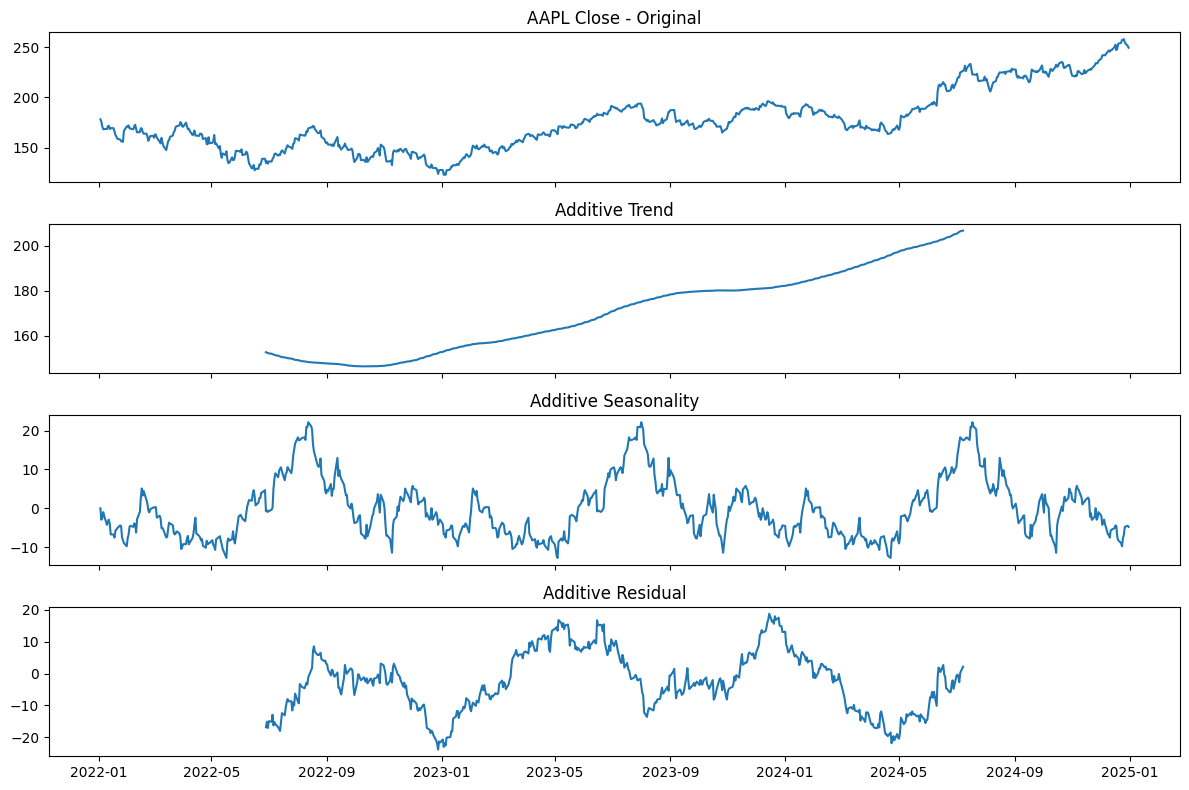

In [5]:
"""
Seasonal decomposition of AAPL Close into trend, seasonal, residual
for both additive and multiplicative models. Period ~252 trading days.
"""

period = 252  # approx 1 trading year

aapl_add = seasonal_decompose(aapl_data['Close'], model='additive', period=period)
aapl_mul = seasonal_decompose(aapl_data['Close'], model='multiplicative', period=period)

# Plot additive decomposition for inspection
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(aapl_data['Close']); axes[0].set_title('AAPL Close - Original')
axes[1].plot(aapl_add.trend); axes[1].set_title('Additive Trend')
axes[2].plot(aapl_add.seasonal); axes[2].set_title('Additive Seasonality')
axes[3].plot(aapl_add.resid); axes[3].set_title('Additive Residual')
plt.tight_layout()
plt.show()


In [6]:
"""
Compare residual variance of additive vs multiplicative decomposition
and choose the one with lower residual variance as the working model.
"""

add_resid_var = np.nanvar(aapl_add.resid)
mul_resid_var = np.nanvar(aapl_mul.resid)

print("Additive residual variance:", add_resid_var)
print("Multiplicative residual variance:", mul_resid_var)

if mul_resid_var < add_resid_var:
    print("Using MULTIPLICATIVE decomposition.")
    aapl_trend = aapl_mul.trend
    aapl_seasonal = aapl_mul.seasonal
    aapl_resid = aapl_mul.resid
else:
    print("Using ADDITIVE decomposition.")
    aapl_trend = aapl_add.trend
    aapl_seasonal = aapl_add.seasonal
    aapl_resid = aapl_add.resid

# Drop initial NaNs created by decomposition
decomp_df = pd.DataFrame({
    'Close': aapl_data['Close'],
    'Trend': aapl_trend,
    'Seasonal': aapl_seasonal,
    'Residual': aapl_resid
}).dropna()

decomp_df.tail()


Additive residual variance: 90.06484842687496
Multiplicative residual variance: 0.00317628735178491
Using MULTIPLICATIVE decomposition.


,Close,Trend,Seasonal,Residual
Date,,,,
2024-07-02,218.784058,205.506298,1.076465,0.988987
2024-07-03,220.055389,205.799273,1.085582,0.984976
2024-07-04,220.055389,206.085854,1.095971,0.974282
2024-07-05,224.813065,206.358081,1.103604,0.987158
2024-07-08,226.283112,206.620626,1.098307,0.997137


In [7]:
"""
Split decomposed series into train/test based on time (80/20).
We will model the RESIDUAL component and reconstruct Close later.
"""

split_idx = int(len(decomp_df) * 0.8)
aapl_train_df = decomp_df.iloc[:split_idx]
aapl_test_df  = decomp_df.iloc[split_idx:]

aapl_train_resid = aapl_train_df['Residual']
aapl_test_resid  = aapl_test_df['Residual']

aapl_train_close = aapl_train_df['Close']
aapl_test_close  = aapl_test_df['Close']

aapl_train_df.shape, aapl_test_df.shape


((424, 4), (106, 4))

In [8]:
"""
Check stationarity of the residuals on the train set.
Residuals should be close to stationary; differencing only if needed.
"""

print("ADF p (residual train):", adfuller(aapl_train_resid)[1])
print("KPSS p (residual train):", kpss(aapl_train_resid, nlags='auto')[1])


ADF p (residual train): 0.026766373912388747
KPSS p (residual train): 0.01


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_3036/2250683286.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("KPSS p (residual train):", kpss(aapl_train_resid, nlags='auto')[1])


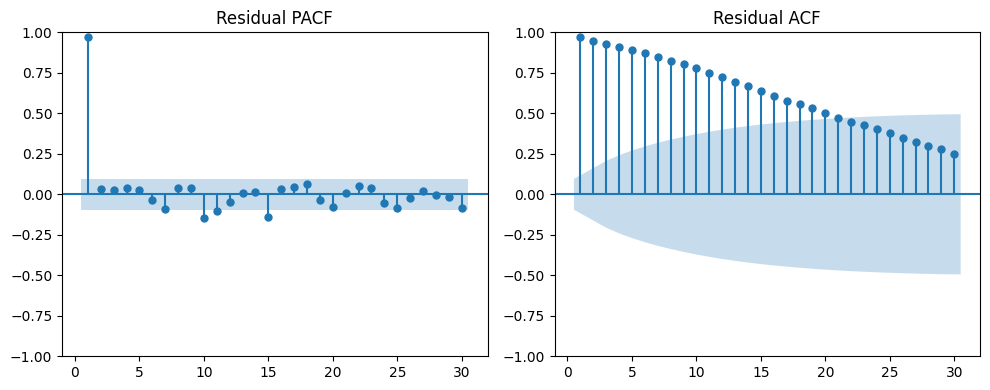

In [9]:
"""
Plot ACF and PACF of residuals to guide ARIMA(p,d,q) on residuals.
"""

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_pacf(aapl_train_resid, lags=30, ax=ax[0], zero=False)
ax[0].set_title("Residual PACF")
plot_acf(aapl_train_resid, lags=30, ax=ax[1], zero=False)
ax[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()


In [10]:
"""
Fit ARIMA on residuals only, forecast residuals on test horizon,
then reconstruct Close = Trend + Seasonal + Residual_forecast
and evaluate MSE in Close space.
"""

# Fit ARIMA on residuals (tune order as desired)
aapl_resid_arima = ARIMA(aapl_train_resid, order=(1, 0, 1))
aapl_resid_arima_fit = aapl_resid_arima.fit()

# Forecast residuals for test length
resid_forecast_arima = aapl_resid_arima_fit.forecast(steps=len(aapl_test_resid))

# Reconstruct Close on test window
trend_test = aapl_test_df['Trend']
season_test = aapl_test_df['Seasonal']

close_forecast_arima = trend_test + season_test + resid_forecast_arima
aapl_mse_arima = mean_squared_error(aapl_test_close, close_forecast_arima)

print("AAPL ARIMA-on-residual MSE (Close space):", aapl_mse_arima)


AAPL ARIMA-on-residual MSE (Close space): 351.4902881494493


In [11]:
"""
Create supervised lagged dataset from residuals for ML models.
"""

def make_lagged(series, nlags=60):
    s = pd.Series(series).reset_index(drop=True)
    nlags = min(nlags, len(s) - 2)
    out = pd.DataFrame({'y': s})
    for i in range(1, nlags + 1):
        out[f'lag_{i}'] = s.shift(i)
    return out.dropna()


In [12]:
"""
Lag-60 dataset for residuals, train Linear Regression and Random Forest.
"""

nlags = 60
aapl_resid_lagged = make_lagged(aapl_train_resid, nlags=nlags)

X_resid = aapl_resid_lagged.drop(columns='y')
y_resid = aapl_resid_lagged['y']

aapl_lr = LinearRegression()
aapl_lr.fit(X_resid, y_resid)

aapl_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)
aapl_rf.fit(X_resid, y_resid)

X_resid.shape, y_resid.shape


((364, 60), (364,))

In [13]:
"""
Recursive multi-step forecasting of residuals with LR and RF,
then reconstruction of Close on the test window and MSE computation.
"""

feature_names = [f'lag_{i}' for i in range(1, nlags + 1)]

# --- Linear Regression residual forecast ---
lr_resid_preds = []
last_vals_lr = aapl_train_resid.reset_index(drop=True).iloc[-nlags:].values

for _ in range(len(aapl_test_resid)):
    X_input = pd.DataFrame([last_vals_lr], columns=feature_names)
    pred = aapl_lr.predict(X_input)[0]
    lr_resid_preds.append(pred)
    last_vals_lr = np.append(last_vals_lr[1:], pred)

# Reconstruct LR Close forecast
close_forecast_lr = trend_test + season_test + lr_resid_preds
aapl_mse_lr = mean_squared_error(aapl_test_close, close_forecast_lr)

# --- Random Forest residual forecast ---
rf_resid_preds = []
last_vals_rf = aapl_train_resid.reset_index(drop=True).iloc[-nlags:].values

for _ in range(len(aapl_test_resid)):
    X_input = pd.DataFrame([last_vals_rf], columns=feature_names)
    pred = aapl_rf.predict(X_input)[0]
    rf_resid_preds.append(pred)
    last_vals_rf = np.append(last_vals_rf[1:], pred)

close_forecast_rf = trend_test + season_test + rf_resid_preds
aapl_mse_rf = mean_squared_error(aapl_test_close, close_forecast_rf)

print("AAPL LR-on-residual MSE (Close space):", aapl_mse_lr)
print("AAPL RF-on-residual MSE (Close space):", aapl_mse_rf)


AAPL LR-on-residual MSE (Close space): 352.86165304027577
AAPL RF-on-residual MSE (Close space): 352.8347957753378


In [95]:
"""
Recursive ML forecasting for 60 future days.
Each prediction feeds into the next lag window.
"""

feature_names = [f'lag_{i}' for i in range(1, 61)]

# --- Linear Regression ---
lr_preds = []
last_vals = aapl_train['Close'].reset_index(drop=True).iloc[-60:].values

for _ in range(len(aapl_test)):
    X_input = pd.DataFrame([last_vals[::-1]], columns=feature_names)
    pred = aapl_lr.predict(X_input)[0]
    lr_preds.append(pred)
    last_vals = np.append(last_vals[1:], pred)

aapl_mse_lr = mean_squared_error(aapl_test['Close'], lr_preds)

# --- Random Forest ---
rf_preds = []
last_vals = aapl_train['Close'].reset_index(drop=True).iloc[-60:].values

for _ in range(len(aapl_test)):
    X_input = pd.DataFrame([last_vals[::-1]], columns=feature_names)
    pred = aapl_rf.predict(X_input)[0]
    rf_preds.append(pred)
    last_vals = np.append(last_vals[1:], pred)

aapl_mse_rf = mean_squared_error(aapl_test['Close'], rf_preds)

print("AAPL LR MSE:", aapl_mse_lr)
print("AAPL RF MSE:", aapl_mse_rf)


AAPL LR MSE: 2388.3439423331165
AAPL RF MSE: 1255.7327522321082


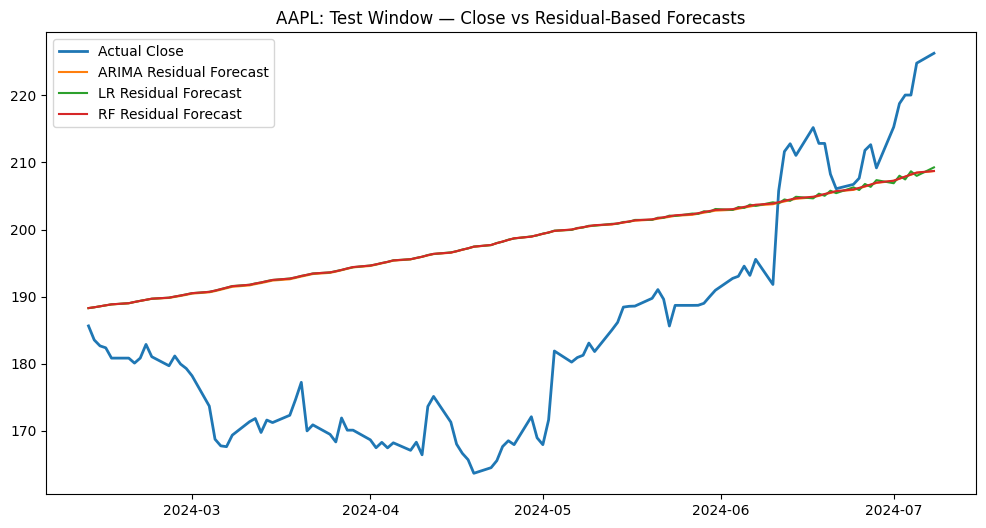

In [14]:
"""
Plot Actual Close vs reconstructed forecasts from ARIMA, LR, RF
for the test horizon.
"""

plt.figure(figsize=(12, 6))
plt.plot(aapl_test_close.index, aapl_test_close, label='Actual Close', linewidth=2)
plt.plot(aapl_test_close.index, close_forecast_arima, label='ARIMA Residual Forecast')
plt.plot(aapl_test_close.index, close_forecast_lr, label='LR Residual Forecast')
plt.plot(aapl_test_close.index, close_forecast_rf, label='RF Residual Forecast')
plt.title("AAPL: Test Window — Close vs Residual-Based Forecasts")
plt.legend()
plt.show()


In [15]:
"""
Refit models on FULL residual series, forecast 60 future residuals,
extrapolate trend, repeat last seasonal cycle, and reconstruct Close.
"""

# --- Prepare full residual / trend / seasonal series (drop NaNs) ---
full_df = decomp_df.copy()  # already dropped NaNs earlier
full_resid = full_df['Residual']
full_trend = full_df['Trend']
full_season = full_df['Seasonal']

# --- Refit residual ARIMA ---
full_resid_arima = ARIMA(full_resid, order=(1, 0, 1))
full_resid_arima_fit = full_resid_arima.fit()
future_resid_arima = full_resid_arima_fit.forecast(steps=60)

# --- Refit LR & RF on full residuals ---
full_resid_lagged = make_lagged(full_resid, nlags=nlags)
X_full_resid = full_resid_lagged.drop(columns='y')
y_full_resid = full_resid_lagged['y']

full_lr = LinearRegression().fit(X_full_resid, y_full_resid)
full_rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_full_resid, y_full_resid)

# Recursive future residuals (LR & RF)
feature_names = [f'lag_{i}' for i in range(1, nlags + 1)]

# LR
lr_future_resid = []
last_vals_lr = full_resid.reset_index(drop=True).iloc[-nlags:].values

for _ in range(60):
    X_input = pd.DataFrame([last_vals_lr], columns=feature_names)
    pred = full_lr.predict(X_input)[0]
    lr_future_resid.append(pred)
    last_vals_lr = np.append(last_vals_lr[1:], pred)

# RF
rf_future_resid = []
last_vals_rf = full_resid.reset_index(drop=True).iloc[-nlags:].values

for _ in range(60):
    X_input = pd.DataFrame([last_vals_rf], columns=feature_names)
    pred = full_rf.predict(X_input)[0]
    rf_future_resid.append(pred)
    last_vals_rf = np.append(last_vals_rf[1:], pred)

# --- Build future trend via simple linear extrapolation ---
trend_clean = full_trend.dropna()
t_idx = np.arange(len(trend_clean))
coef = np.polyfit(t_idx, trend_clean.values, deg=1)
t_future_idx = np.arange(len(trend_clean), len(trend_clean) + 60)
trend_future = coef[0] * t_future_idx + coef[1]

# --- Build future seasonality by repeating last 'period' values ---
season_vals = full_season[-period:].values
season_future = [season_vals[i % period] for i in range(60)]

# --- Future date index ---
freq = aapl_data.index.freq or aapl_data.index.inferred_freq or 'B'
last_date = full_df.index[-1]
future_idx = pd.date_range(start=last_date + pd.tseries.frequencies.to_offset(freq),
                           periods=60, freq=freq)

# --- Reconstruct future Close for each model ---
close_future_arima = trend_future + season_future + future_resid_arima.values
close_future_lr    = trend_future + season_future + np.array(lr_future_resid)
close_future_rf    = trend_future + season_future + np.array(rf_future_resid)

# Assemble DataFrame
aapl_future_forecasts = pd.DataFrame({
    'ARIMA_Close_Forecast': close_future_arima,
    'LR_Close_Forecast': close_future_lr,
    'RF_Close_Forecast': close_future_rf
}, index=future_idx)

aapl_future_forecasts.to_csv('AAPL_decomp_final_forecasts.csv')
aapl_future_forecasts.head()


,ARIMA_Close_Forecast,LR_Close_Forecast,RF_Close_Forecast
2024-07-09,202.774135,202.685576,202.669299
2024-07-10,202.889331,202.794437,202.781188
2024-07-11,203.005007,202.910653,202.894191
2024-07-12,203.119790,203.018297,203.010157
2024-07-15,203.230072,203.134637,203.131008


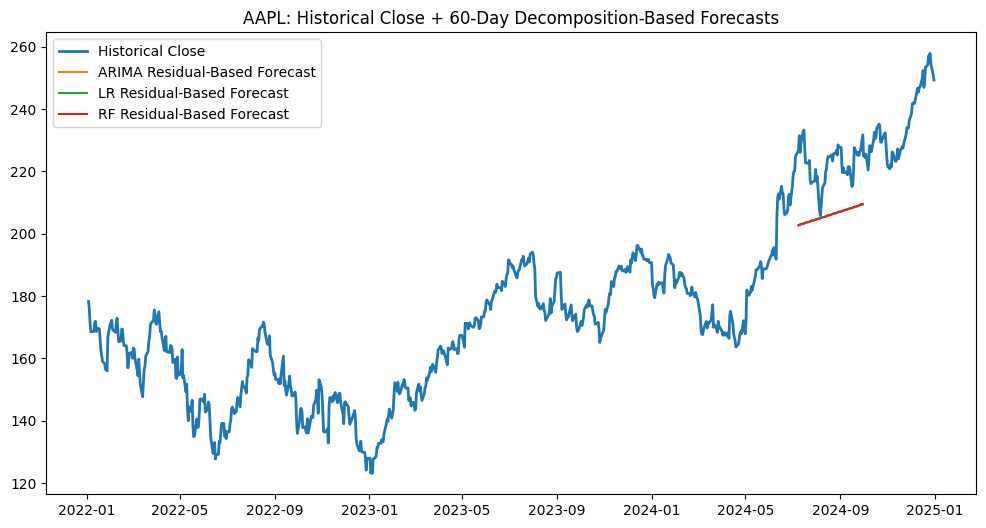

In [16]:
"""
Plot historical Close plus 60-day reconstructed forecasts
from ARIMA, LR, and RF (all residual-based with trend+season).
"""

plt.figure(figsize=(12, 6))
plt.plot(aapl_data['Close'], label='Historical Close', linewidth=2)
plt.plot(aapl_future_forecasts.index, aapl_future_forecasts['ARIMA_Close_Forecast'],
         label='ARIMA Residual-Based Forecast')
plt.plot(aapl_future_forecasts.index, aapl_future_forecasts['LR_Close_Forecast'],
         label='LR Residual-Based Forecast')
plt.plot(aapl_future_forecasts.index, aapl_future_forecasts['RF_Close_Forecast'],
         label='RF Residual-Based Forecast')

plt.title("AAPL: Historical Close + 60-Day Decomposition-Based Forecasts")
plt.legend()
plt.show()


# Another test'; Seasonally Adjusted Series Forecasting

In [17]:
"""
Load AAPL historical data, enforce business day frequency, clean values.
"""

aapl_data = pd.read_csv('AAPL_historical.csv')
aapl_data['Date'] = pd.to_datetime(aapl_data['Date'])
aapl_data = aapl_data.set_index('Date').sort_index()

aapl_data = aapl_data.asfreq('B')
aapl_data['Close'] = pd.to_numeric(aapl_data['Close'], errors='coerce').ffill()

aapl_data.tail()


,Close
Date,
2024-12-25,257.037476
2024-12-26,257.853790
2024-12-27,254.439224
2024-12-30,251.064499
2024-12-31,249.292511


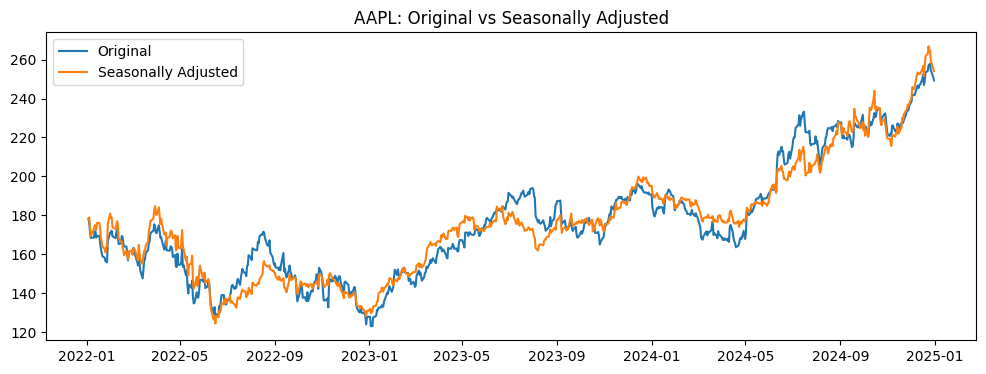

In [18]:
"""
Perform seasonal decomposition to extract the seasonal component.
We will remove seasonality but KEEP the trend.
"""

period = 252  # trading-year period

aapl_add = seasonal_decompose(aapl_data['Close'], model='additive', period=period)
aapl_season = aapl_add.seasonal

# Seasonally Adjusted Close (SA series)
aapl_sa = aapl_data['Close'] - aapl_season

# Remove NaNs created by decomposition
aapl_sa = aapl_sa.dropna()
aapl_season = aapl_season.loc[aapl_sa.index]

plt.figure(figsize=(12,4))
plt.plot(aapl_data['Close'], label='Original')
plt.plot(aapl_sa, label='Seasonally Adjusted')
plt.title('AAPL: Original vs Seasonally Adjusted')
plt.legend()
plt.show()


In [20]:
"""
80–20 split on SEASONALLY ADJUSTED SERIES.
"""

split_idx = int(len(aapl_sa) * 0.8)

aapl_train_sa = aapl_sa.iloc[:split_idx]
aapl_test_sa  = aapl_sa.iloc[split_idx:]

aapl_train_season = aapl_season.iloc[:split_idx]
aapl_test_season  = aapl_season.iloc[split_idx:]

aapl_train_sa.shape, aapl_test_sa.shape


((625,), (157,))

In [21]:
"""
ADF + KPSS on seasonally adjusted training series.
"""

print("ADF p:", adfuller(aapl_train_sa)[1])
print("KPSS p:", kpss(aapl_train_sa)[1])


ADF p: 0.6111122650283481
KPSS p: 0.01


/var/folders/db/ggx093sn7jd57knx244_768r0000gn/T/ipykernel_3036/2198612313.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("KPSS p:", kpss(aapl_train_sa)[1])


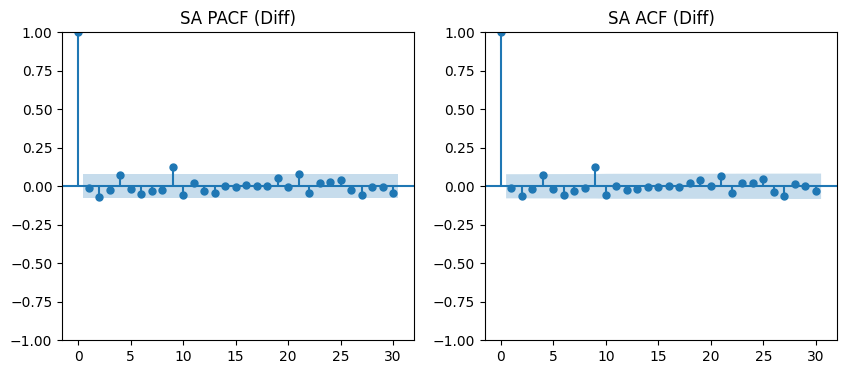

In [22]:
"""
Plot ACF/PACF to help choose ARIMA(p,d,q) on seasonally adjusted series.
"""

fig, ax = plt.subplots(1, 2, figsize=(10,4))
plot_pacf(aapl_train_sa.diff().dropna(), lags=30, ax=ax[0])
plot_acf(aapl_train_sa.diff().dropna(), lags=30, ax=ax[1])
ax[0].set_title("SA PACF (Diff)")
ax[1].set_title("SA ACF (Diff)")
plt.show()


In [23]:
"""
Fit ARIMA on seasonally adjusted training data.
"""

arima_sa = ARIMA(aapl_train_sa, order=(1,1,1))
arima_sa_fit = arima_sa.fit()
arima_sa_fit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  625
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1420.764
Date:                Fri, 21 Nov 2025   AIC                           2847.529
Time:                        17:09:03   BIC                           2860.837
Sample:                    01-03-2022   HQIC                          2852.700
                         - 05-24-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6814      0.388      1.755      0.079      -0.080       1.442
ma.L1         -0.7107      0.377     -1.883      0.060      -1.450       0.029
sigma2         5.5613      0.209     26.596      0.000       5.151       5.971
===================================================================================
Ljung-Box (L1) (Q):                   0.19   Jarque-Bera (JB):               185.68
Prob(Q):                              0.66   Prob(JB):                         0.00
Heteroskedasticity (H):               0.32   Skew:                            -0.21
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
"""
Forecast SEASONALLY ADJUSTED test values, then reintegrate seasonality.
"""

sa_pred_arima = arima_sa_fit.forecast(steps=len(aapl_test_sa))

# Add seasonal component back:
final_arima_pred = sa_pred_arima + aapl_test_season

# Test actual Close = SA + season
actual_test_close = aapl_test_sa + aapl_test_season

# MSE in Close space
aapl_mse_arima = mean_squared_error(actual_test_close, final_arima_pred)
print("ARIMA (seasonally adjusted) MSE:", aapl_mse_arima)


ARIMA (seasonally adjusted) MSE: 1513.9077362060093


In [25]:
"""
Standard lag feature generator for ML forecasting.
"""

def make_lagged(series, nlags=60):
    s = pd.Series(series).reset_index(drop=True)
    nlags = min(nlags, len(s)-2)
    out = pd.DataFrame({'y': s})
    for i in range(1, nlags+1):
        out[f'lag_{i}'] = s.shift(i)
    return out.dropna()


In [26]:
"""
Create lagged version of SEASONALLY ADJUSTED series and fit ML models.
"""

nlags = 60
sa_lagged = make_lagged(aapl_train_sa, nlags=nlags)
X_sa = sa_lagged.drop(columns='y')
y_sa = sa_lagged['y']

lr_sa = LinearRegression().fit(X_sa, y_sa)
rf_sa = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_sa, y_sa)


In [27]:
"""
Recursive prediction of seasonally adjusted values using LR & RF.
"""

feature_names = [f'lag_{i}' for i in range(1, nlags+1)]

# LR
lr_preds_sa = []
last_vals = aapl_train_sa.reset_index(drop=True).iloc[-nlags:].values

for _ in range(len(aapl_test_sa)):
    X_input = pd.DataFrame([last_vals], columns=feature_names)
    pred = lr_sa.predict(X_input)[0]
    lr_preds_sa.append(pred)
    last_vals = np.append(last_vals[1:], pred)

# RF
rf_preds_sa = []
last_vals = aapl_train_sa.reset_index(drop=True).iloc[-nlags:].values

for _ in range(len(aapl_test_sa)):
    X_input = pd.DataFrame([last_vals], columns=feature_names)
    pred = rf_sa.predict(X_input)[0]
    rf_preds_sa.append(pred)
    last_vals = np.append(last_vals[1:], pred)


In [28]:
"""
Convert SA predictions -> Close predictions by adding seasonality.
"""

lr_final_pred = np.array(lr_preds_sa) + aapl_test_season.values
rf_final_pred = np.array(rf_preds_sa) + aapl_test_season.values

mse_lr = mean_squared_error(actual_test_close, lr_final_pred)
mse_rf = mean_squared_error(actual_test_close, rf_final_pred)

print("LR MSE (Close space):", mse_lr)
print("RF MSE (Close space):", mse_rf)


LR MSE (Close space): 2152.2126033234535
RF MSE (Close space): 2104.689421205913


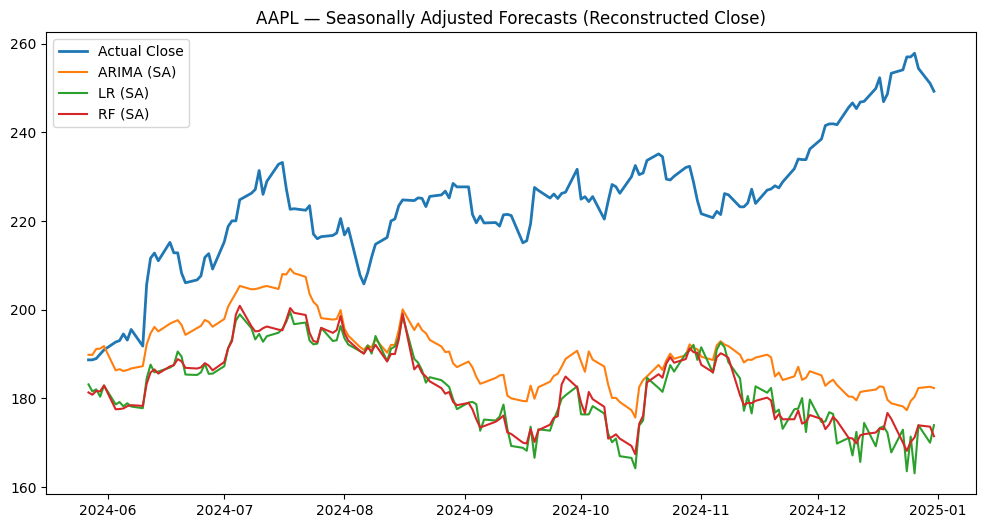

In [29]:
plt.figure(figsize=(12,6))
plt.plot(actual_test_close.index, actual_test_close, label='Actual Close', linewidth=2)
plt.plot(actual_test_close.index, final_arima_pred, label='ARIMA (SA)')
plt.plot(actual_test_close.index, lr_final_pred, label='LR (SA)')
plt.plot(actual_test_close.index, rf_final_pred, label='RF (SA)')
plt.title("AAPL — Seasonally Adjusted Forecasts (Reconstructed Close)")
plt.legend()
plt.show()

/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


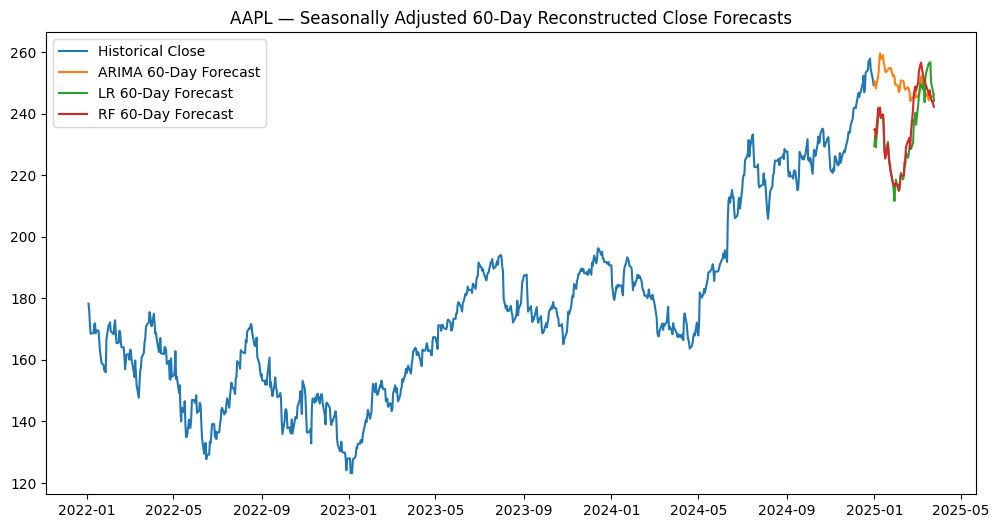

In [30]:
"""
Refit all models on FULL seasonally adjusted series,
forecast 60 days ahead, then add seasonality to reconstruct Close.
"""

# --- SEASONALLY ADJUSTED FULL SERIES ---
full_sa = aapl_sa
full_season = aapl_season

# --- Refit ARIMA ---
full_arima_sa = ARIMA(full_sa, order=(1,1,1)).fit()
future_sa_arima = full_arima_sa.forecast(60)

# --- Refit ML ---
full_sa_lagged = make_lagged(full_sa, nlags=nlags)
X_full_sa = full_sa_lagged.drop(columns='y')
y_full_sa = full_sa_lagged['y']

lr_full = LinearRegression().fit(X_full_sa, y_full_sa)
rf_full = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42).fit(X_full_sa, y_full_sa)

# Recursive predictions (ML)
# LR
future_lr_sa = []
last_vals_lr = full_sa.reset_index(drop=True).iloc[-nlags:].values
for _ in range(60):
    X_input = pd.DataFrame([last_vals_lr], columns=feature_names)
    pred = lr_full.predict(X_input)[0]
    future_lr_sa.append(pred)
    last_vals_lr = np.append(last_vals_lr[1:], pred)

# RF
future_rf_sa = []
last_vals_rf = full_sa.reset_index(drop=True).iloc[-nlags:].values
for _ in range(60):
    X_input = pd.DataFrame([last_vals_rf], columns=feature_names)
    pred = rf_full.predict(X_input)[0]
    future_rf_sa.append(pred)
    last_vals_rf = np.append(last_vals_rf[1:], pred)

# --- FUTURE DATES ---
freq = aapl_data.index.freq or 'B'
future_idx = pd.date_range(start=aapl_data.index[-1] + pd.tseries.frequencies.to_offset(freq),
                           periods=60, freq=freq)

# --- CREATE FUTURE SEASONALITY (repeat last cycle) ---
season_vals = full_season[-period:].values
future_season = [season_vals[i % period] for i in range(60)]

# --- FINAL RECONSTRUCTED CLOSE FORECASTS ---
close_future_arima = future_sa_arima.values + future_season
close_future_lr = np.array(future_lr_sa) + future_season
close_future_rf = np.array(future_rf_sa) + future_season

# Save
pd.DataFrame({
    'ARIMA_Close_Forecast': close_future_arima,
    'LR_Close_Forecast': close_future_lr,
    'RF_Close_Forecast': close_future_rf
}, index=future_idx).to_csv('AAPL_optionB_60day_forecast.csv')

# Plot
plt.figure(figsize=(12,6))
plt.plot(aapl_data['Close'], label='Historical Close')
plt.plot(future_idx, close_future_arima, label='ARIMA 60-Day Forecast')
plt.plot(future_idx, close_future_lr, label='LR 60-Day Forecast')
plt.plot(future_idx, close_future_rf, label='RF 60-Day Forecast')
plt.title("AAPL — Seasonally Adjusted 60-Day Reconstructed Close Forecasts")
plt.legend()
plt.show()


# 60 day forecast

## AAPL

/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

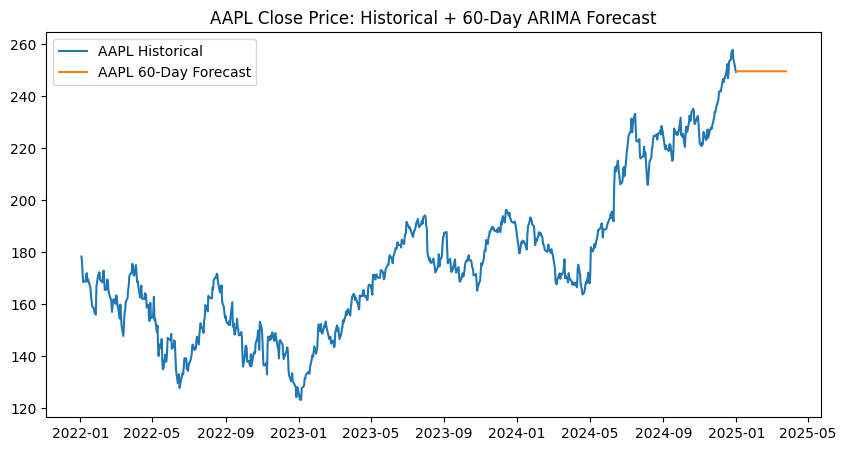

In [74]:
"""
Refits the chosen ARIMA model for AAPL on the full dataset (train + test),
generates a 60-day out-of-sample forecast, builds a Date index for the
forecast horizon, saves results to AAPL_forecasts.csv, and plots the
historical series with the forecast extension.
"""

# Refit ARIMA on full AAPL data
aapl_final_model = ARIMA(aapl_data['Close'], order=(2, 1, 1))
aapl_final_fit = aapl_final_model.fit()

# 60-step forecast
aapl_forecast_values = aapl_final_fit.forecast(steps=60)

# Build future date index using inferred frequency (fallback to business days)
aapl_freq = aapl_data.index.freq or aapl_data.index.inferred_freq or 'B'
aapl_last_date = aapl_data.index[-1]
aapl_future_idx = pd.date_range(start=aapl_last_date + pd.tseries.frequencies.to_offset(aapl_freq),
                                periods=60, freq=aapl_freq)

# Assemble forecast DataFrame
aapl_forecast_df = pd.DataFrame({
    'Date': aapl_future_idx,
    'Close': aapl_forecast_values
}).set_index('Date')

# Save to CSV
aapl_forecast_df.to_csv('AAPL_forecasts.csv')

# Plot historical + forecast
plt.figure(figsize=(10, 5))
plt.plot(aapl_data['Close'], label='AAPL Historical')
plt.plot(aapl_forecast_df['Close'], label='AAPL 60-Day Forecast')
plt.legend()
plt.title('AAPL Close Price: Historical + 60-Day ARIMA Forecast')
plt.show()


/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

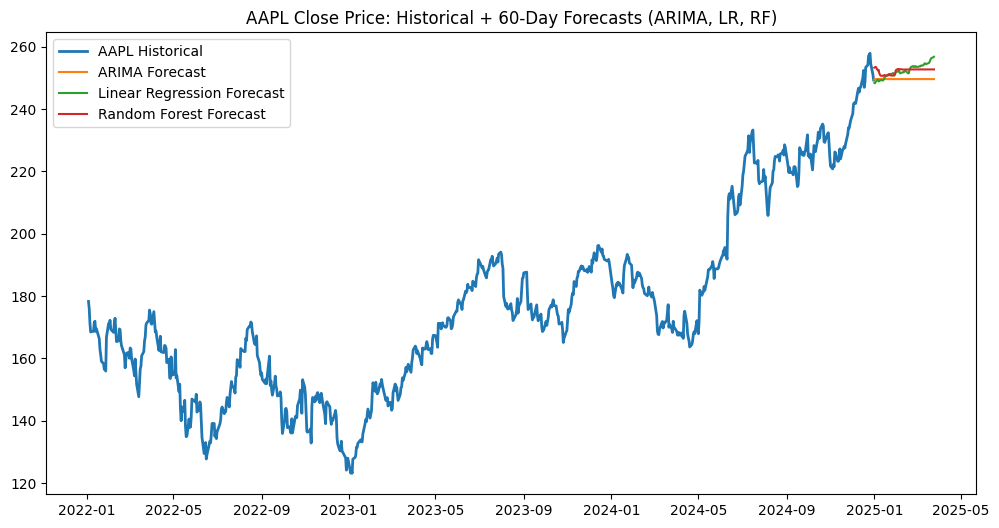

In [75]:
"""
Final 60-day forecasting for AAPL using:
1. ARIMA(2,1,1)
2. Linear Regression with 60 lag features
3. Random Forest with 60 lag features

Refits all models on the FULL dataset, generates 60-day forecasts,
constructs a future Date index, saves all forecasts in a single CSV,
and plots historical vs forecasted values.
"""

# ============================================================
# 1. --- REFIT MODELS ON FULL DATA ----------------------------
# ============================================================

# ----- ARIMA -----
aapl_final_arima = ARIMA(aapl_data['Close'], order=(2, 1, 1))
aapl_arima_fit = aapl_final_arima.fit()

# ----- Build 60-lag dataset on FULL data -----
aapl_full_lagged = make_lagged(aapl_data['Close'], nlags=60)

aapl_X_full = aapl_full_lagged.drop(columns='y')
aapl_y_full = aapl_full_lagged['y']

# ----- Linear Regression -----
aapl_lr_full = LinearRegression()
aapl_lr_full.fit(aapl_X_full, aapl_y_full)

# ----- Random Forest -----
aapl_rf_full = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)
aapl_rf_full.fit(aapl_X_full, aapl_y_full)

# ============================================================
# 2. --- 60-DAY FORECASTING -----------------------------------
# ============================================================

# Common future date index
aapl_freq = aapl_data.index.freq or aapl_data.index.inferred_freq or 'B'
aapl_last_date = aapl_data.index[-1]

aapl_future_idx = pd.date_range(
    start=aapl_last_date + pd.tseries.frequencies.to_offset(aapl_freq),
    periods=60,
    freq=aapl_freq
)

# ----- ARIMA Forecast -----
aapl_arima_forecast = aapl_arima_fit.forecast(steps=60)

# ----- Linear Regression Recursive Forecast -----
lr_preds = []
feature_names = [f'lag_{i}' for i in range(1, 61)]
last_vals = aapl_data['Close'].reset_index(drop=True).iloc[-60:].values

for _ in range(60):
    X_input = pd.DataFrame([last_vals[::-1]], columns=feature_names)
    pred = aapl_lr_full.predict(X_input)[0]
    lr_preds.append(pred)
    last_vals = np.append(last_vals[1:], pred)

# ----- Random Forest Recursive Forecast -----
rf_preds = []
last_vals = aapl_data['Close'].reset_index(drop=True).iloc[-60:].values

for _ in range(60):
    X_input = pd.DataFrame([last_vals[::-1]], columns=feature_names)
    pred = aapl_rf_full.predict(X_input)[0]
    rf_preds.append(pred)
    last_vals = np.append(last_vals[1:], pred)

# ============================================================
# 3. --- ASSEMBLE FORECAST DATAFRAME --------------------------
# ============================================================

aapl_forecast_df = pd.DataFrame({
    'Date': aapl_future_idx,
    'ARIMA_Forecast': aapl_arima_forecast.values,
    'LR_Forecast': lr_preds,
    'RF_Forecast': rf_preds
}).set_index('Date')

# ============================================================
# 4. --- SAVE TO CSV -------------------------------------------
# ============================================================

aapl_forecast_df.to_csv('AAPL_forecasts_full.csv')

# ============================================================
# 5. --- PLOT RESULTS ------------------------------------------
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(aapl_data['Close'], label='AAPL Historical', linewidth=2)
plt.plot(aapl_future_idx, aapl_arima_forecast, label='ARIMA Forecast')
plt.plot(aapl_future_idx, lr_preds, label='Linear Regression Forecast')
plt.plot(aapl_future_idx, rf_preds, label='Random Forest Forecast')

plt.title("AAPL Close Price: Historical + 60-Day Forecasts (ARIMA, LR, RF)")
plt.legend()
plt.show()


## MSFT

/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/migssantiago/Library/Python/3.13/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will 

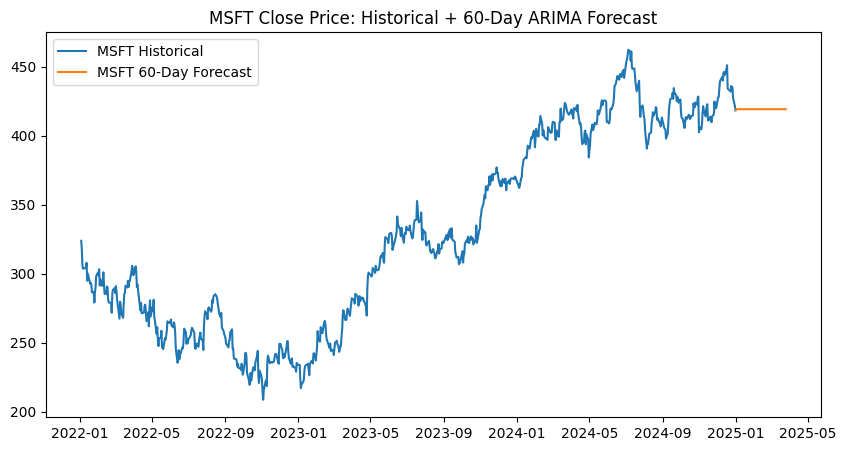

In [30]:
"""
Refits the chosen ARIMA model for MSFT on the full dataset (train + test),
generates a 60-day out-of-sample forecast, builds a Date index for the
forecast horizon, saves results to MSFT_forecasts.csv, and plots the
historical series with the forecast extension.
"""

# Refit ARIMA on full MSFT data
msft_final_model = ARIMA(msft_data['Close'], order=(2, 1, 1))
msft_final_fit = msft_final_model.fit()

# 60-step forecast
msft_forecast_values = msft_final_fit.forecast(steps=60)

# Build future date index using inferred frequency (fallback to business days)
msft_freq = msft_data.index.freq or msft_data.index.inferred_freq or 'B'
msft_last_date = msft_data.index[-1]
msft_future_idx = pd.date_range(start=msft_last_date + pd.tseries.frequencies.to_offset(msft_freq),
                                periods=60, freq=msft_freq)

# Assemble forecast DataFrame
msft_forecast_df = pd.DataFrame({
    'Date': msft_future_idx,
    'Close': msft_forecast_values
}).set_index('Date')

# Save to CSV
msft_forecast_df.to_csv('MSFT_forecasts.csv')

# Plot historical + forecast
plt.figure(figsize=(10, 5))
plt.plot(msft_data['Close'], label='MSFT Historical')
plt.plot(msft_forecast_df['Close'], label='MSFT 60-Day Forecast')
plt.legend()
plt.title('MSFT Close Price: Historical + 60-Day ARIMA Forecast')
plt.show()


In [31]:
print(msft_mse_arima)
print(msft_mse_naive)


257.0651159373861
260.1133295695608
